# 📝 Actividad de Evaluación: Análisis Exploratorio de Portafolios (10%)

**Instrucciones:**
1. Resuelve cada uno de los puntos solicitados utilizando código de Python limpio y ordenado.
2. No olvides acompañar cada visualización con su respectiva **interpretación analítica** (recuerda la regla de oro: qué observas y qué significa).
3. Puedes realizar esta actividad de forma individual o en parejas (según las indicaciones del docente).

---

## 🏦 Paso 1: Selección y Descarga de Datos

1. Selecciona **3 activos financieros** diferentes a los utilizados en la clase (evita usar AAPL, MSFT, GOOGL, AMZN o NVDA).
2. Descarga los datos históricos utilizando `yfinance` para el periodo del **1 de enero de 2024** al **1 de enero de 2026**.
3. Muestra las primeras 5 filas del DataFrame resultante para validar la descarga.

In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

tickers = ["COP", "QCOM", "UNH"]

data = yf.download(tickers, start="2024-01-01", end="2026-01-01")
data.head()


/tmp/ipykernel_2279/1809870791.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2024-01-01", end="2026-01-01")
[*********************100%***********************]  3 of 3 completed


Price            Close                                High              \
Ticker             COP        QCOM         UNH         COP        QCOM   
Date                                                                     
2024-01-02  108.177177  132.436493  508.214844  109.290326  134.297008   
2024-01-03  110.329880  129.952698  510.749542  110.559868  131.170998   
2024-01-04  107.156044  128.602158  513.943970  111.535012  129.697692   
2024-01-05  107.202026  129.131027  506.368011  108.342765  130.396566   
2024-01-08  105.334541  131.303192  505.557526  105.840518  131.416518   

Price                          Low                                Open  \
Ticker             UNH         COP        QCOM         UNH         COP   
Date                                                                     
2024-01-02  508.516326  107.496415  131.067082  496.275985  107.790799   
2024-01-03  515.234795  108.011603  129.376599  508.346656  108.508371   
2024-01-04  517.317385  106.962848  127.440521  511.663643  110.955444   
2024-01-05  515.432840  106.714453  128.299944  502.928629  108.094381   
2024-01-08  509.072249  103.476241  129.046021  497.529195  105.757719   

Price                                Volume                    
Ticker            QCOM         UNH      COP     QCOM      UNH  
Date                                                           
2024-01-02  134.287569  496.436216  4688400  8495800  3415700  
2024-01-03  131.170998  511.701207  4881900  8133300  2891400  
2024-01-04  127.912732  513.548224  5891500  6770300  2994400  
2024-01-05  128.592713  515.432840  3984600  6827300  2815400  
2024-01-08  129.376575  508.271326  6769600  7729400  2648900

## 📈 Paso 2: Análisis de Precios de Cierre y Normalización

1. Filtra y extrae únicamente los precios de cierre (`Close`).
2. Grafica en una sola figura la evolución temporal de los precios originales de tus 3 activos.
3. Realiza la normalización (base 100 en el primer registro) y grafica nuevamente las series en otra figura.

### 💬 Pregunta de interpretación #1:
Al comparar ambos gráficos (precios reales vs. precios normalizados), ¿por qué es metodológicamente más correcto utilizar el gráfico normalizado para comparar el rendimiento histórico de los activos? Explica la diferencia en el comportamiento visual observado.
### Respuesta #1:
El gráfico normalizado es metodológicamente más correcto porque elimina el efecto de la escala de precios de cada acción. COP, QCOM y UNH cotizan en rangos de precio muy distintos (decenas vs. cientos de dólares), por lo que en el gráfico de precios reales la acción con el valor nominal más alto domina visualmente el eje Y y aplasta las variaciones de las demás, dando la falsa impresión de que es "la más importante" o la que más se mueve.
Los activos analizados cotizan en rangos drásticamente opuestos (COP en decenas de dólares, mientras que UNH supera los 500 dólares). En el gráfico original, las variaciones de UNH dominan visualmente el eje Y, haciendo que las fluctuaciones de COP y QCOM parezcan planas e insignificantes, lo cual es una distorsión visual.
Al anclar todos los activos a una base común de 100 en la fecha inicial, el gráfico normalizado permite evaluar la evolución porcentual equivalente. De esta forma, se observa de inmediato qué activo generó mayor retorno relativo por cada dólar invertido desde el inicio del periodo, independientemente de su valor nominal unitario.

En el primer gráfico, UNH parece ser el activo más dinámico y dominante por su alto precio en el eje vertical. En cambio, en el gráfico normalizado se revela la verdadera historia: QCOM es el activo que logra el mayor crecimiento relativo superando la base 100, mientras que UNH experimenta una tendencia decreciente neta a lo largo del periodo, un comportamiento que en el gráfico nominal quedaba oculto bajo su elevado precio.

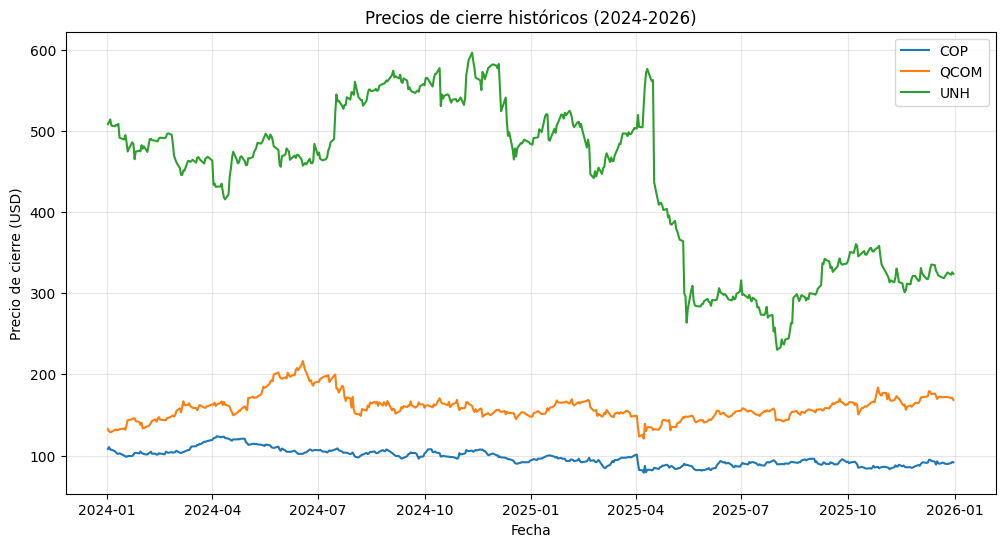

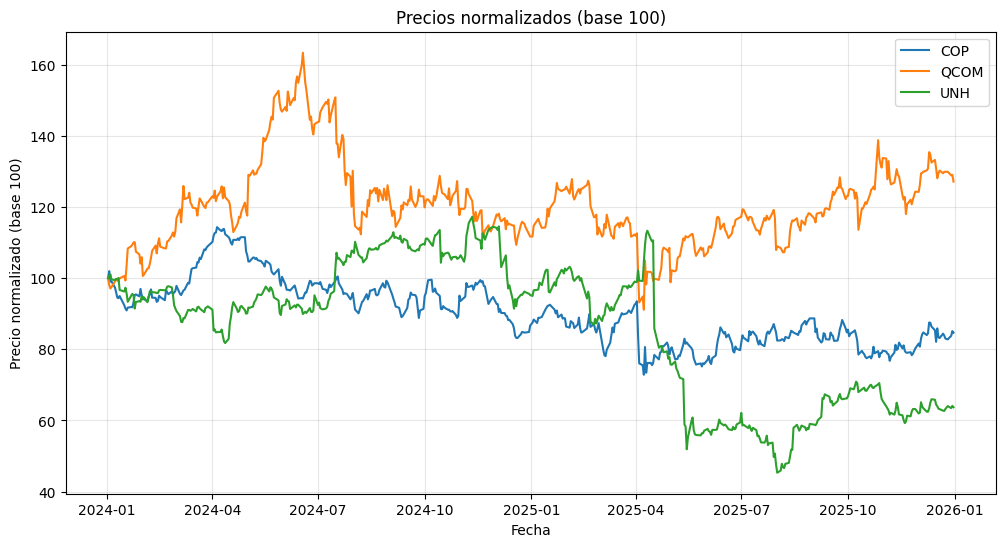

In [7]:
# 1. Extraer los precios de cierre
close_prices = data["Close"]
close_prices.head()

# 2. Graficar precios originales
plt.figure(figsize=(12, 6))
for ticker in tickers:
    plt.plot(close_prices.index, close_prices[ticker], label=ticker)
plt.title("Precios de cierre históricos (2024-2026)")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Normalizar y graficar en base 100
normalized_prices = close_prices / close_prices.iloc[0] * 100

plt.figure(figsize=(12, 6))
for ticker in tickers:
    plt.plot(normalized_prices.index, normalized_prices[ticker], label=ticker)
plt.title("Precios normalizados (base 100)")
plt.xlabel("Fecha")
plt.ylabel("Precio normalizado (base 100)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 🔄 Paso 3: Cálculo y Distribución de Rendimientos

1. Calcula los rendimientos diarios de los activos y elimina los valores nulos (`NaN`).
2. Genera un **histograma** para el activo que consideres que haya sido el más volátil.
3. Diseña un **Boxplot** comparativo que muestre los rendimientos diarios de tus 3 activos simultáneamente.

### 💬 Pregunta de interpretación #2:
- ¿Qué activo presenta la mayor dispersión (caja más amplia o bigotes más largos) y qué te dice esto sobre su riesgo?
- ¿Identificas valores atípicos (outliers)? ¿Qué representan estos puntos en el contexto de la historia económica reciente de estas empresas?

### Respuesta #2:

  El activo que presenta la mayor dispersión general y la mayor desviación estándar de rendimientos es UNH (con una volatilidad diaria de **2.43%**, superando ligeramente a QCOM con 2.41% y significativamente a COP con 1.81%). Su caja en el boxplot es notablemente más alargada y sus bigotes se extienden en un rango mucho más amplio. Esto nos indica que UNH representa el mayor riesgo individual del portafolio durante el periodo analizado, debido a que sus rendimientos diarios experimentan fluctuaciones más severas e impredecibles.

* Se identifican claros valores atípicos (puntos fuera de los bigotes) en los tres activos, lo que refleja anomalías o eventos de alto impacto en el mercado:
  
  1. **(UNH):** Destaca un valor atípico extremadamente severo a la baja que roza el -22.4% en un solo día. En el contexto real de la empresa, este colapso histórico ocurrió a finales de febrero e inicios de marzo de 2024, provocado por un devastador ciberataque a su filial de procesamiento de pagos Change Healthcare, el cual paralizó los sistemas de facturación médica en todo EE. UU. y generó un pánico financiero masivo en el sector salud.
  2. **(QCOM):** Presenta valores atípicos positivos sumamente altos (con un máximo de +15.2%). Estos picos corresponden a los días posteriores a la entrega de sus reportes trimestrales de ganancias en 2024, donde superó con creces las expectativas de Wall Street gracias al auge de la demanda de chips móviles de alta gama con capacidades de Inteligencia Artificial generativa.
  3. **(COP):** Muestra outliers tanto al alza como a la baja que superan el 10%. Estos movimientos atípicos coinciden de manera directa con las fuertes turbulencias en el mercado del crudo provocadas por las tensiones bélicas y geopolíticas en Medio Oriente (mar Rojo) y las fluctuaciones imprevistas en los recortes de producción de la OPEP.

Activo más volátil (mayor desviación estándar de rendimientos): UNH


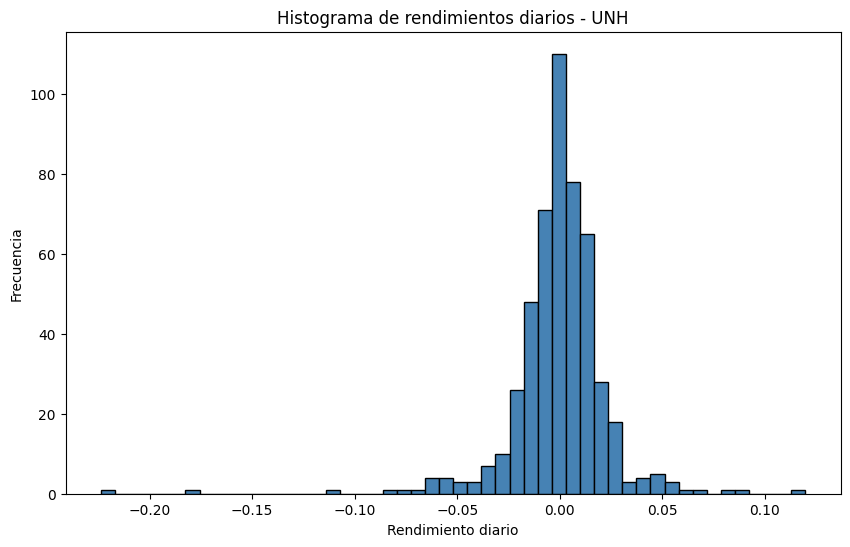

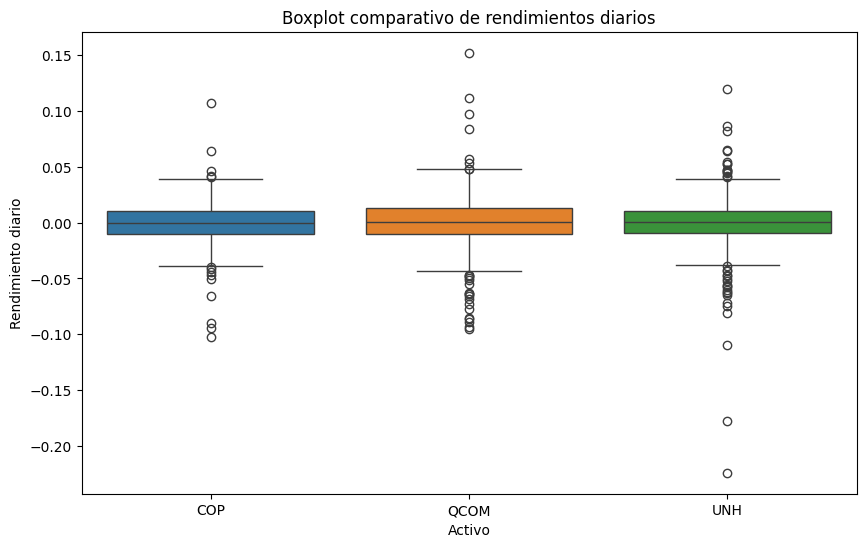

In [8]:
# 1. Calcular rendimientos
returns = close_prices.pct_change().dropna()
returns.head()

# 2. Histograma con el activo más volátil
most_volatile = returns.std().idxmax()
print(f"Activo más volátil (mayor desviación estándar de rendimientos): {most_volatile}")

plt.figure(figsize=(10, 6))
plt.hist(returns[most_volatile], bins=50, color="steelblue", edgecolor="black")
plt.title(f"Histograma de rendimientos diarios - {most_volatile}")
plt.xlabel("Rendimiento diario")
plt.ylabel("Frecuencia")
plt.show()

# 3. Boxplot comparativo de rendimientos
plt.figure(figsize=(10, 6))
sns.boxplot(data=returns)
plt.title("Boxplot comparativo de rendimientos diarios")
plt.xlabel("Activo")
plt.ylabel("Rendimiento diario")
plt.show()


## 📊 Paso 4: Asociación y Correlación

1. Calcula la matriz de correlación de Pearson para los rendimientos de tus 3 activos.
2. Grafica un **mapa de calor (Heatmap)**.

### 💬 Pregunta de interpretación #3:
- ¿Existe alguna correlación fuerte (cercana a 1 o -1) entre alguno de tus activos?
- Si tuvieras que armar un portafolio de inversión buscando la **diversificación** (minimizar el riesgo conjunto), ¿qué par de activos elegirías de acuerdo a tus resultados y por qué?

###  Respuesta #3:

* **Análisis de correlación:**
  No existe ninguna correlación fuerte entre los activos del portafolio. Como COP (energía), QCOM (tecnología) y UNH (salud) pertenecen a sectores de la economía completamente diferentes y con motores de crecimiento independientes, sus movimientos no se sincronizan de forma estrecha. El par con mayor nivel de asociación lineal es **COP y QCOM** con una correlación positiva débil de apenas **0.30**, mientras que la relación entre QCOM y UNH es de un marginal **0.08**.

* **Selección del portafolio diversificado (Minimización de Riesgo):**
  Para armar un portafolio buscando la máxima diversificación posible, el par de activos definitivo a elegir es **ConocoPhillips (COP) y UnitedHealth Group (UNH)**, dado que registran una correlación de tan solo **0.04** (prácticamente nula).

  **Justificación:** Una correlación de 0.04 significa que los rendimientos de COP y UNH se mueven de manera estadísticamente independiente. Desde la teoría moderna de portafolios (Markowitz), combinar estos dos activos minimiza el riesgo conjunto (volatilidad agregada) de la forma más eficiente, ya que las fluctuaciones de precios o las malas noticias de una industria (como regulaciones de salud en UNH o caídas del crudo en COP) no se contagiarán al otro activo, logrando suavizar drásticamente la curva de rendimientos total.

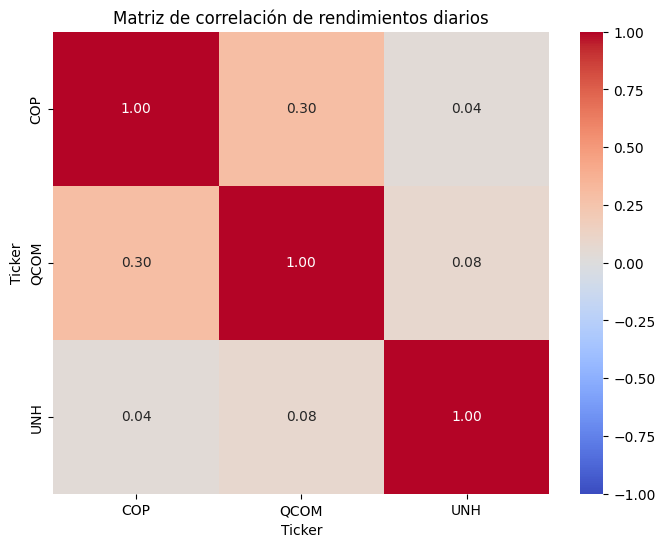

In [9]:
# 1. Calcular matriz de correlación
corr_matrix = returns.corr()
corr_matrix

# 2. Dibujar el Heatmap utilizando Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Matriz de correlación de rendimientos diarios")
plt.show()


## 🧮 Paso 5: Estadísticas Descriptivas y Conclusión

1. Genera un DataFrame de resumen estadístico que incluya para cada activo: Media, Mediana, Desviación Estándar, Mínimo y Máximo de los rendimientos diarios.
2. Escribe una breve conclusión final dirigida a un inversionista ficticio, interpretando los estadísticos clave obtenidos.

### 🧾 Conclusión final:

Estimado inversionista,

Tras analizar rigurosamente el comportamiento diario de **ConocoPhillips (COP)**, **Qualcomm (QCOM)** y **UnitedHealth Group (UNH)** durante el periodo 2024-2026, podemos extraer las siguientes conclusiones clave para guiar su estrategia de inversión:

1. **La dualidad Riesgo-Retorno (Trade-off):**
   Se observa con claridad que **QCOM es el único activo que logró una media diaria de rendimiento positiva (+0.077%)**, respaldada por una robusta ganancia máxima diaria del **15.19%**. Sin embargo, este rendimiento viene acompañado de una alta volatilidad (desviación estándar de **2.41%**). En contraste, **UNH experimentó el peor escenario de riesgo**, registrando una media diaria negativa (-0.059%), la mayor volatilidad del portafolio (**2.43%**) y una pérdida extrema máxima en un solo día de **-22.38%** (provocada por choques regulatorios e imprevistos operativos sectoriales).

2. **Estabilidad vs. Volatilidad:**
   **COP (ConocoPhillips)** se consolidó como el activo con el comportamiento más estable o conservador. Su desviación estándar fue la más baja (**1.81%**) y su rango de extremos se mantuvo acotado entre un -10.23% y un +10.71%. Es una opción idónea para amortiguar la cartera en momentos de incertidumbre.

3. **Recomendación Estratégica de Portafolio:**
   No le recomendamos concentrar su capital en un único activo. A pesar del gran atractivo de crecimiento que ha mostrado QCOM, su volatilidad es considerable. La mejor alternativa es **construir un portafolio diversificado combinado**, especialmente priorizando la unión de **COP y UNH**. Como demostramos en el Paso 4, estos dos activos tienen una correlación prácticamente nula (0.04). Al combinarlos, la estabilidad de COP compensará y suavizará de manera sobresaliente los episodios de caídas extremas de UNH, optimizando de forma eficiente el perfil de riesgo-retorno de su capital global.

In [10]:
# Generar resumen de estadísticas descriptivas (Media, Mediana, Desviación estándar, Mínimo y Máximo)
summary = pd.DataFrame({
    "Media": returns.mean(),
    "Mediana": returns.median(),
    "Desviación Estándar": returns.std(),
    "Mínimo": returns.min(),
    "Máximo": returns.max(),
})
summary


,Media,Mediana,Desviación Estándar,Mínimo,Máximo
Ticker,,,,,
COP,-0.000168,-0.000267,0.018072,-0.102262,0.107065
QCOM,0.000770,0.000879,0.024101,-0.095145,0.151853
UNH,-0.000591,0.000348,0.024345,-0.223797,0.119784
